# Fewview tutorial

[Fewview](https://github.com/bjl1u25/fewview) turns a
[FastEMRIWaveforms](https://github.com/BlackHolePerturbationToolkit/FastEMRIWaveforms)
waveform into a full-sky, retarded-time picture of the gravitational wave. The
relativistic `FastKerrEccentricEquatorialFlux` modes are reconstructed into
$h_{\ell m}(t)$, combined with spin-weighted spherical harmonics over the whole
sky, and evaluated at $u = t_{\rm frame} - r/c$ throughout a sphere, so the wave
is seen radiating outward from the source.

This notebook generates a waveform and renders a still, tries a couple of
different looks, and previews a short animation. It assumes Fewview is
installed into the same environment as your FastEMRIWaveforms install
(`pip install fewview`).

## 1. Imports

In [1]:
import numpy as np
from IPython.display import Image, Video, display

import fewview as fv

print("Fewview", fv.__version__)
print("colour schemes:", fv.available_color_schemes())
print("opacity profiles:", fv.OPACITY_PROFILES)

Fewview 0.1.0
colour schemes: ('aurora', 'blues', 'cinematic', 'cividis', 'cool', 'inferno', 'magma', 'plasma', 'rainbow', 'viridis')
opacity profiles: ('soft', 'bands', 'shells', 'flux')


## 2. Generate a waveform

`generate_relativistic_mode_waveform` runs the fully relativistic FEW model and
returns a `RelativisticModeWaveform`, which carries the individual
$h_{\ell m}(t)$ modes and the FEW inspiral trajectory. This is the one slow step
(tens of seconds); everything after it is fast.

The amplitude model is trained up to `nmax=55`; asking for more emits a warning
and uses the trained set.

In [2]:
waveform = fv.generate_relativistic_mode_waveform(
    M=1.0e6,   # primary mass [Msun]
    mu=10.0,   # secondary mass [Msun]
    a=0.9,     # dimensionless spin
    p0=12.0,   # initial semi-latus rectum
    e0=0.4,    # initial eccentricity
    xI0=1.0,   # equatorial, prograde
    dt=10.0,   # seconds
    T=0.01,    # years
    lmax=10,
    nmax=55,
)
print(
    f"{waveform.modes.shape[1]} (l,m) modes reconstructed from "
    f"{waveform.teukolsky_modes_used}/{waveform.teukolsky_modes_available} "
    "Teukolsky modes"
)

117 (l,m) modes reconstructed from 6993/6993 Teukolsky modes


## 3. Choose how much history to show

The sphere maps waveform history from its centre (the current frame) to its
edge. `choose_max_delay` picks a span containing a resolvable number of wave
cycles. A small number of cycles keeps the shells well separated, matching the
scale of a black-hole-merger volume render.

In [3]:
reference = waveform.strain(theta=np.pi / 3.0, phi=0.0)
h_plus, h_cross = np.real(reference), -np.imag(reference)

period = fv.estimate_waveform_period(waveform.time, h_plus, h_cross)
max_delay = fv.choose_max_delay(waveform.time, h_plus, h_cross, wave_cycles=1.5)
end = float(waveform.time[-1])
print(f"local period {period:.0f} s; showing {max_delay:.0f} s of history")

local period 1023 s; showing 1535 s of history


## 4. Render a still

`render_mode_frame` builds the volume for one instant and renders it. The look
is set by three choices:

- **`component`** — `plus` has no equatorial node and is the usual choice.
- **`opacity_profile`** — `shells` draws nested translucent signed-strain
  sheets.
- **`color_scheme`** — `rainbow` is a smooth blue-to-red sequence tuned for
  those shells.

The central bodies are drawn on the orbit's own scale (the primary spans a few
horizon radii), with a fading inspiral trail behind the secondary.

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Widget(value='<iframe src="http://localhost:60589/index.html?ui=P_0x1c45285c0_0&reconnect=auto" class="pyvista…

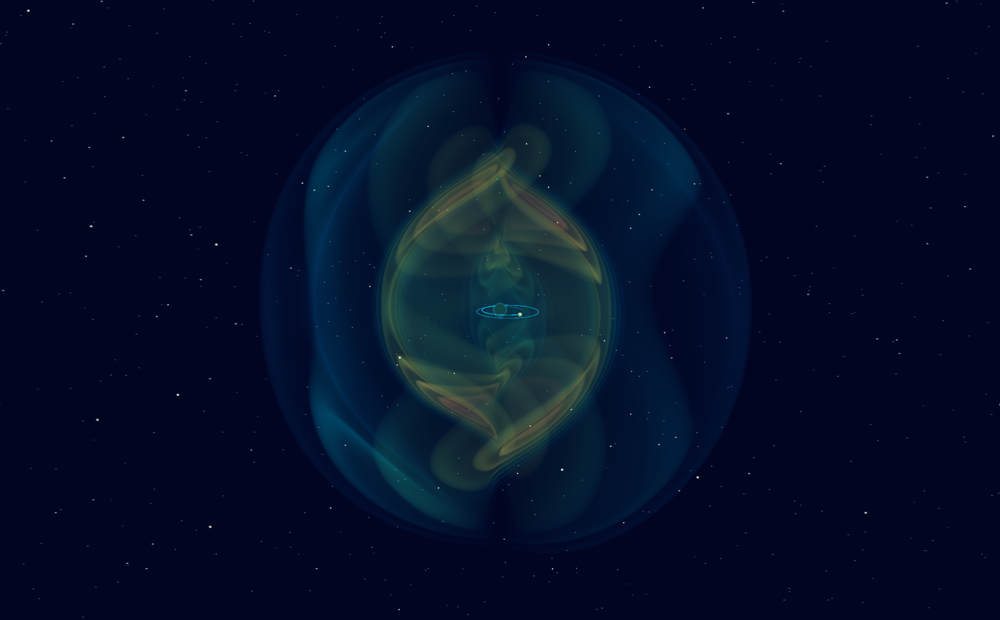

In [4]:
still = fv.render_mode_frame(
    waveform,
    screenshot="fewview-tutorial-shells.png",
    max_delay=max_delay,
    frame_time=end,
    waveform_start_time=end - 8 * period,
    waveform_end_time=end,
    resolution=200,
    component="plus",
    opacity_profile="shells",
    color_scheme="rainbow",
    presentation="shells_dramatic",
    camera_view="oblique",
    camera_zoom=0.95,
    shell_count=7,
    shell_min=0.10,
    shell_max=0.92,
    smooth_sigma=1.2,
    inner_window_fraction=0.10,
    outer_window_fraction=0.10,
    trajectory_color="#00b7ff",
    show_waveform=False,
    window_size=(1000, 620),
)
display(Image(filename="fewview-tutorial-shells.png"))

## 5. A different look: face-on

The `camera_view="face_on"` option looks straight down the spin axis, which
reveals the spiral wavefront pattern. Any palette works; `cool` gives a calm
blue-to-magenta sequence. This is the same `shells` profile as before, only the
camera and colours change.

Widget(value='<iframe src="http://localhost:60589/index.html?ui=P_0x1bf3bea80_0&reconnect=auto" class="pyvista…

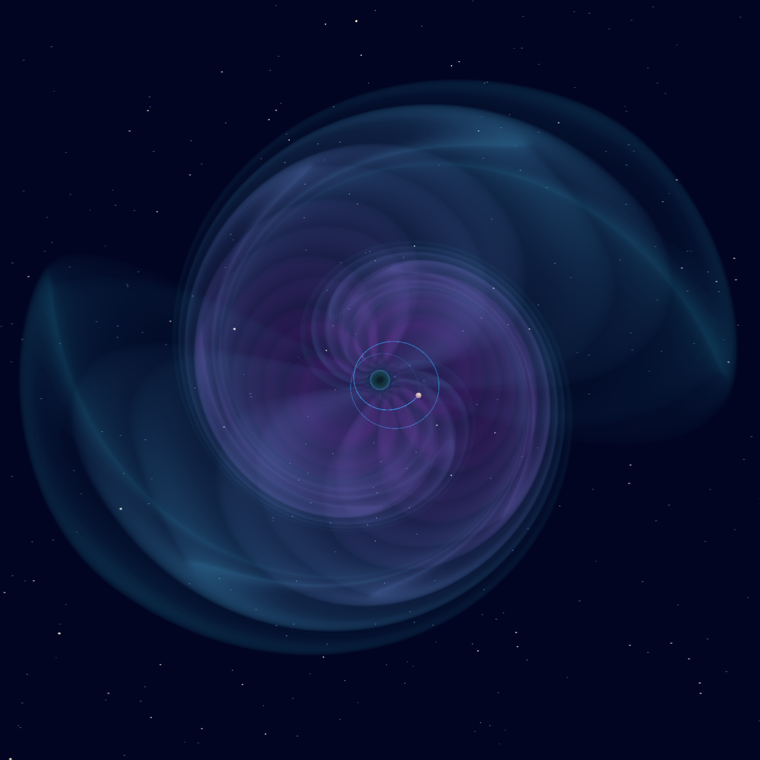

In [5]:
faceon_still = fv.render_mode_frame(
    waveform,
    screenshot="fewview-tutorial-faceon.png",
    max_delay=max_delay,
    frame_time=end,
    waveform_start_time=end - 8 * period,
    waveform_end_time=end,
    resolution=200,
    component="plus",
    opacity_profile="shells",
    color_scheme="cool",
    presentation="shells_dramatic",
    camera_view="face_on",
    camera_zoom=1.1,
    shell_count=7,
    shell_min=0.10,
    shell_max=0.92,
    smooth_sigma=1.2,
    inner_window_fraction=0.10,
    outer_window_fraction=0.10,
    trajectory_color="#00b7ff",
    show_waveform=False,
    window_size=(760, 760),
)
display(Image(filename="fewview-tutorial-faceon.png"))

## 6. Quick diagnostic: a 2D slice

Before committing to a full render, a coordinate-plane slice through the volume
is a fast way to see the field. This is much cheaper than a volume render.

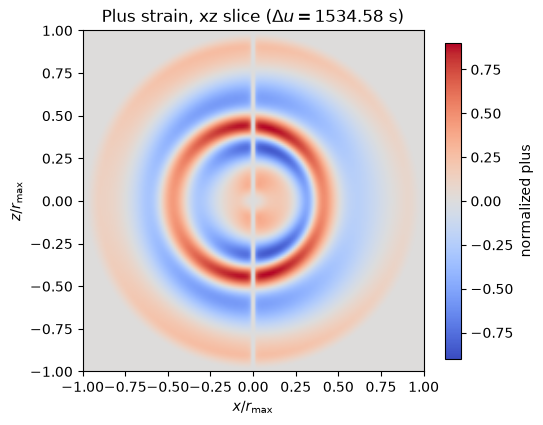

In [6]:
import matplotlib.pyplot as plt

volume = fv.build_mode_retarded_time_volume(
    waveform,
    frame_time=end,
    max_delay=max_delay,
    resolution=160,
    inner_window_fraction=0.10,
    outer_window_fraction=0.10,
)
fig, _ = fv.plot_volume_slice(volume, component="plus", plane="xz")
fig.set_size_inches(5.5, 5.0)
plt.show()

## 7. A short animation

`render_mode_animation` sweeps a range of frame times to an MP4, reusing the
angular basis across frames and holding the colour scale fixed so the movie does
not flicker. This is the expensive step; the preview below is deliberately small
and short.

`--animation-cycles` controls how much inspiral is traversed, and the frame
count controls how smoothly. Aim for at least ~20 frames per wave cycle.

In [7]:
anim_end = end
anim_start = max(float(waveform.time[0] + max_delay), anim_end - 3.0 * period)

movie = fv.render_mode_animation(
    waveform,
    "fewview-tutorial.mp4",
    max_delay=max_delay,
    start_time=anim_start,
    end_time=anim_end,
    frames=24,
    fps=12,
    resolution=110,
    component="plus",
    opacity_profile="shells",
    color_scheme="rainbow",
    presentation="shells_dramatic",
    camera_view="oblique",
    camera_zoom=0.95,
    shell_count=7,
    smooth_sigma=1.2,
    inner_window_fraction=0.10,
    outer_window_fraction=0.10,
    trajectory_color="#00b7ff",
    show_waveform=True,
    window_size=(640, 400),
    normalization_samples=3,
)
display(Video(str(movie), width=640))

Widget(value='<iframe src="http://localhost:60589/index.html?ui=P_0x1bf54d610_0&reconnect=auto" class="pyvista…

## Where to go next

- **Components**: `plus`, `cross` (zero on the equator), `amplitude`
  (basis-independent), and `energy_flux` (pair it with `opacity_profile="flux"`).
- **Palettes**: any Matplotlib colormap plus `rainbow`, `aurora`, `cinematic`.
  See `fv.available_color_schemes()`.
- **Camera**: `camera_view="face_on"` looks down the spin axis;
  `camera_zoom` frames the sphere.
- **Cluster rendering**: for long 4K movies, `fewview-cluster-job` generates a
  Slurm array. See `docs/cluster_rendering.md`.

Two physical notes. The **polar axis** carries a faint unavoidable seam (a
spin-2 field has no continuous scalar representation over the poles). And for
**high eccentricity** the `nmax=55` amplitude cap means some high-overtone
content is missing.